# 03 — Imbalance Handling

Compare four strategies for dealing with the 0.17% fraud rate:
SMOTE, random undersampling, class weights, and SMOTE+Tomek.
Winner (highest PR-AUC) is saved and becomes the baseline for notebook 04.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_curve,
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TEST_SIZE    = 0.2
MODELS_PATH  = Path('../outputs/models')
MODELS_PATH.mkdir(exist_ok=True)

## 1. Load & prep (same pipeline as notebook 02)

In [4]:
df = pd.read_csv('../data/raw/creditcard.csv')
df['log_amount']  = np.log1p(df['Amount'])
df['hour_of_day'] = (df['Time'] // 3600) % 24
df = df.drop(columns=['Time', 'Amount'])

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Train fraud: {y_train.sum()} / {len(y_train):,}")
print(f"Test  fraud: {y_test.sum()} / {len(y_test):,}")

Train fraud: 394 / 227,845
Test  fraud: 98 / 56,962


## 2. Define strategies

Each strategy wraps a `StandardScaler` + resampler + `LogisticRegression` into
an imbalanced-learn `Pipeline` so resampling only ever sees training folds.

In [6]:
strategies = {
    'class_weight_balanced': ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(
                      class_weight='balanced', max_iter=1000,
                      random_state=RANDOM_STATE)),
    ]),
    'random_undersample': ImbPipeline([
        ('scaler',  StandardScaler()),
        ('resample', RandomUnderSampler(random_state=RANDOM_STATE)),
        ('clf',      LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    'smote': ImbPipeline([
        ('scaler',  StandardScaler()),
        ('resample', SMOTE(random_state=RANDOM_STATE)),
        ('clf',      LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    'smote_tomek': ImbPipeline([
        ('scaler',  StandardScaler()),
        ('resample', SMOTETomek(random_state=RANDOM_STATE)),
        ('clf',      LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
}

print(f"{len(strategies)} strategies defined")

4 strategies defined


## 3. Evaluate each strategy

Fit on full training set, score on held-out test set.
PR-AUC is the primary metric — accuracy is meaningless at 0.17% fraud rate.

In [8]:
results      = {}
fitted_models = {}

for name, pipeline in strategies.items():
    pipeline.fit(X_train, y_train)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    prauc  = average_precision_score(y_test, y_prob)
    results[name]       = prauc
    fitted_models[name] = (pipeline, y_prob)
    print(f"{name:30s}  PR-AUC = {prauc:.4f}")

best       = max(results, key=results.get)
best_model = fitted_models[best][0]
best_prob  = fitted_models[best][1]
print(f"\nBest strategy: {best}  (PR-AUC={results[best]:.4f})")

class_weight_balanced           PR-AUC = 0.7129
random_undersample              PR-AUC = 0.6099
smote                           PR-AUC = 0.7186
smote_tomek                     PR-AUC = 0.7186

Best strategy: smote  (PR-AUC=0.7186)


## 4. PR-AUC comparison bar chart

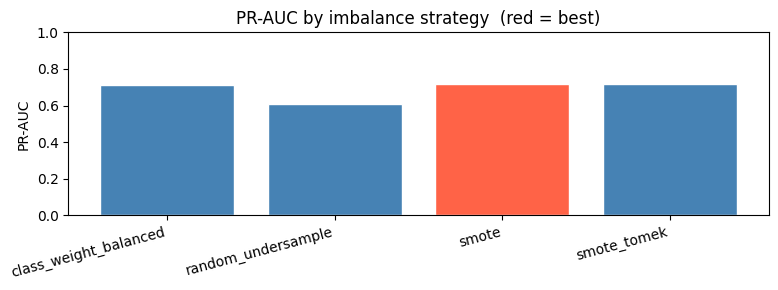

In [10]:
fig, ax = plt.subplots(figsize=(8, 3))
colors = ['tomato' if k == best else 'steelblue' for k in results]
ax.bar(results.keys(), results.values(), color=colors, edgecolor='white')
ax.set_ylabel('PR-AUC')
ax.set_title('PR-AUC by imbalance strategy  (red = best)')
ax.set_ylim(0, 1)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('../outputs/figures/03_strategy_comparison.png')
plt.show()

## 5. PR curves — all strategies overlaid

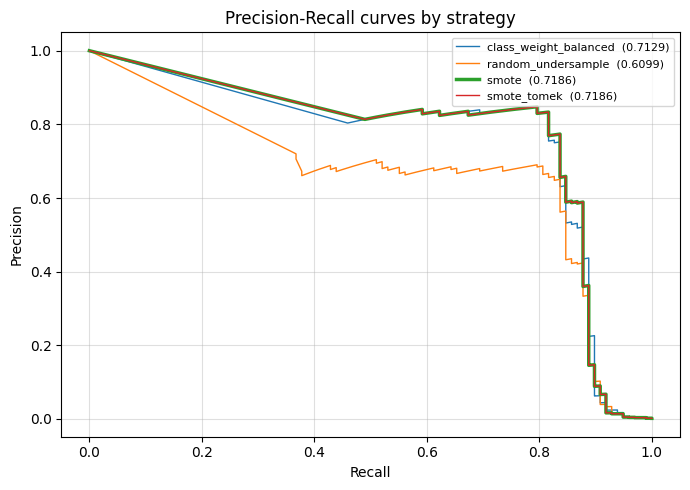

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, (_, y_prob) in fitted_models.items():
    prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob)
    lw = 2.5 if name == best else 1.0
    ax.plot(rec_c, prec_c, lw=lw, label=f"{name}  ({results[name]:.4f})")
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curves by strategy')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/figures/03_pr_curves.png')
plt.show()

## 6. Confusion matrix — best model at threshold 0.5

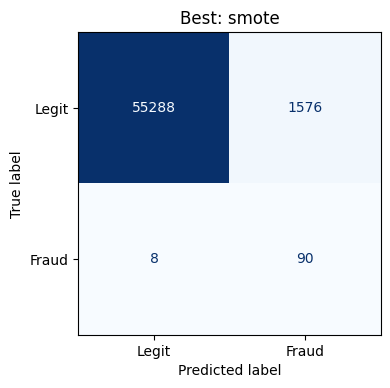

Fraud caught (TP):     90
Fraud missed (FN):     8  <- want this low
False alarms (FP):     1,576  <- want this low
Correct legit (TN):    55,288


In [14]:
y_pred = (best_prob >= 0.5).astype(int)
cm     = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud']).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'Best: {best}')
plt.tight_layout()
plt.savefig('../outputs/figures/03_confusion_matrix.png')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Fraud caught (TP):     {tp:,}")
print(f"Fraud missed (FN):     {fn:,}  <- want this low")
print(f"False alarms (FP):     {fp:,}  <- want this low")
print(f"Correct legit (TN):    {tn:,}")

## 7. Save best model and results

In [16]:
joblib.dump(best_model, MODELS_PATH / 'best_imbalance_model.pkl')
joblib.dump(results,    MODELS_PATH / 'imbalance_results.pkl')
print(f"Saved: models/best_imbalance_model.pkl  ({best})")
print(f"Saved: models/imbalance_results.pkl")
print(f"\nNext: notebook 04 - swap logistic regression for XGBoost")
print(f"Target: beat PR-AUC of {results[best]:.4f}")

Saved: models/best_imbalance_model.pkl  (smote)
Saved: models/imbalance_results.pkl

Next: notebook 04 - swap logistic regression for XGBoost
Target: beat PR-AUC of 0.7186
